# TensorFlow

Sequential API tutorial on the MNIST dataset.

In [7]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

In [8]:
tf.__version__

'2.21.0'

In [9]:
LEARNING_RATE = 0.001
NUM_EPOCHS = 25
BATCH_SIZE = 32

In [10]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

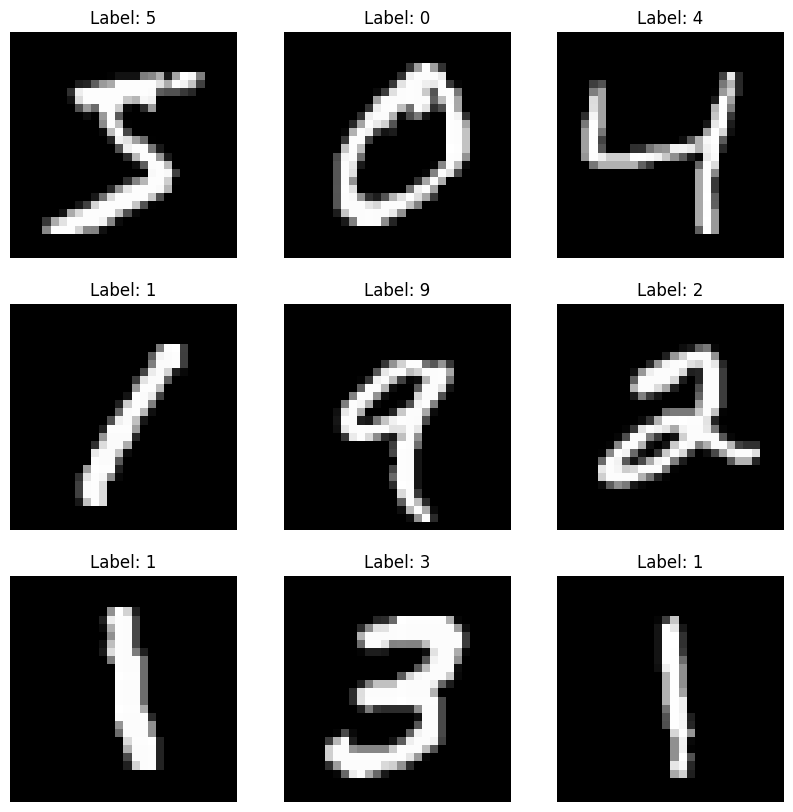

In [12]:
# display examples from the training set 3x3 grid
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for i in range(3):
    for j in range(3):
        axes[i, j].imshow(x_train[i * 3 + j], cmap='gray')
        axes[i, j].set_title(f'Label: {y_train[i * 3 + j]}')
        axes[i, j].axis('off')
plt.show()

In [13]:
# create a model using the Sequential API
model = keras.Sequential([
    keras.layers.Input(shape=(28, 28), name="input"),
    keras.layers.Flatten(name="flatten"),
    keras.layers.Dense(64, activation='relu', name="hidden-1"),
    keras.layers.Dense(10, activation='softmax', name="output")
])

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden-1 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# compile the model
model.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [16]:
# early stopping callback
early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [17]:
# train the model
history = model.fit(x_train, y_train,
                    epochs=NUM_EPOCHS,
                    validation_split=0.15,
                    verbose=2,
                    callbacks=[early_stopping]
)

Epoch 1/25
1594/1594 - 2s - 1ms/step - accuracy: 0.7698 - loss: 2.7395 - val_accuracy: 0.8221 - val_loss: 0.6623
Epoch 2/25
1594/1594 - 1s - 809us/step - accuracy: 0.8576 - loss: 0.5618 - val_accuracy: 0.8882 - val_loss: 0.4565
Epoch 3/25
1594/1594 - 1s - 798us/step - accuracy: 0.8970 - loss: 0.4082 - val_accuracy: 0.9170 - val_loss: 0.3412
Epoch 4/25
1594/1594 - 1s - 804us/step - accuracy: 0.9163 - loss: 0.3265 - val_accuracy: 0.9188 - val_loss: 0.3164
Epoch 5/25
1594/1594 - 1s - 820us/step - accuracy: 0.9254 - loss: 0.2901 - val_accuracy: 0.9297 - val_loss: 0.2957
Epoch 6/25
1594/1594 - 1s - 786us/step - accuracy: 0.9320 - loss: 0.2660 - val_accuracy: 0.9384 - val_loss: 0.2426
Epoch 7/25
1594/1594 - 1s - 797us/step - accuracy: 0.9347 - loss: 0.2529 - val_accuracy: 0.9426 - val_loss: 0.2307
Epoch 8/25
1594/1594 - 1s - 807us/step - accuracy: 0.9387 - loss: 0.2341 - val_accuracy: 0.9374 - val_loss: 0.2375
Epoch 9/25
1594/1594 - 1s - 807us/step - accuracy: 0.9394 - loss: 0.2297 - val_acc

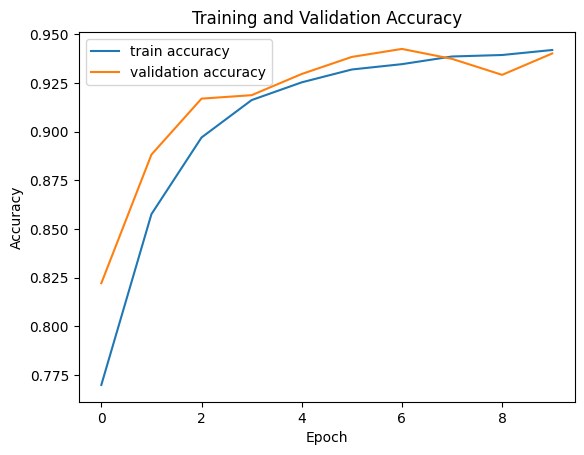

In [18]:
# plot training and validation accuracy
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

In [19]:
# test the model
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Test accuracy: {test_acc:.4f}')

313/313 - 0s - 575us/step - accuracy: 0.9334 - loss: 0.2845
Test accuracy: 0.9334


In [20]:
# do the same thing but with a normalized dataset
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [21]:
# retrain the model with normalized data
history = model.fit(x_train, y_train,
                    batch_size=BATCH_SIZE,
                    epochs=NUM_EPOCHS,
                    validation_split=0.15,
                    verbose=2,
                    callbacks=[early_stopping]
)

Epoch 1/25
1594/1594 - 1s - 922us/step - accuracy: 0.8066 - loss: 0.6453 - val_accuracy: 0.9383 - val_loss: 0.2197
Epoch 2/25
1594/1594 - 1s - 772us/step - accuracy: 0.9368 - loss: 0.2208 - val_accuracy: 0.9538 - val_loss: 0.1661
Epoch 3/25
1594/1594 - 1s - 763us/step - accuracy: 0.9510 - loss: 0.1690 - val_accuracy: 0.9609 - val_loss: 0.1403
Epoch 4/25
1594/1594 - 1s - 773us/step - accuracy: 0.9610 - loss: 0.1339 - val_accuracy: 0.9648 - val_loss: 0.1237
Epoch 5/25
1594/1594 - 1s - 783us/step - accuracy: 0.9686 - loss: 0.1092 - val_accuracy: 0.9693 - val_loss: 0.1110
Epoch 6/25
1594/1594 - 1s - 790us/step - accuracy: 0.9734 - loss: 0.0908 - val_accuracy: 0.9716 - val_loss: 0.1011
Epoch 7/25
1594/1594 - 1s - 763us/step - accuracy: 0.9778 - loss: 0.0763 - val_accuracy: 0.9708 - val_loss: 0.0988
Epoch 8/25
1594/1594 - 1s - 761us/step - accuracy: 0.9805 - loss: 0.0648 - val_accuracy: 0.9739 - val_loss: 0.0919
Epoch 9/25
1594/1594 - 1s - 764us/step - accuracy: 0.9823 - loss: 0.0575 - val_a

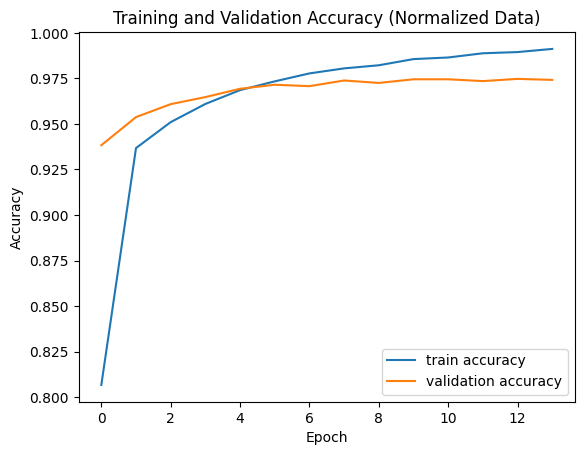

In [22]:
# plot training and validation accuracy
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy (Normalized Data)')
plt.show()

In [23]:
# test the model with normalized data
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Test accuracy (normalized data): {test_acc:.4f}')

313/313 - 0s - 556us/step - accuracy: 0.9736 - loss: 0.0860
Test accuracy (normalized data): 0.9736


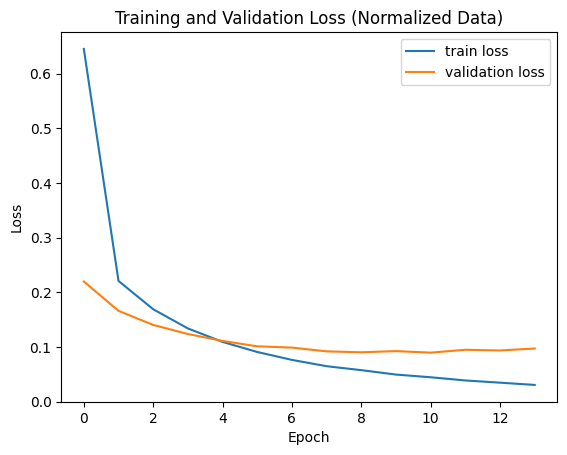

In [24]:
# plot the training and validation loss
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss (Normalized Data)')
plt.show()